In [2]:
!pip install -q langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.3/513.3 kB 26.6 MB/s eta 0:00:00


In [3]:
import os
import json
from pathlib import Path
from getpass import getpass
from typing import Dict, TypedDict, Any, List, Literal

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

### Set model and notebook options

In [ ]:
PREVIEW_ROWS = 5
MAX_CATEGORICAL_VALUES = 12
MAX_CHARTS = 4
NARRATIVE_TABLE_LIMIT = 10

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

### Set CSV input config

In [9]:
CSV_PATH = input("Enter Csv file path: ")

### Define structured schemas

In [26]:
class SchemaProfile(BaseModel):
    file_name: str
    row_count: int
    column_count: int
    numeric_columns: List[str]
    categorical_columns: List[str]
    datetime_columns: List[str]
    text_like_columns: List[str]
    parsed_datetime_columns: List[str]
    duplicate_rows: int
    missing_cells: int

class ChartRecommendation(BaseModel):
    chart_type: Literal["missing_bar", "histogram", "bar", "line", "scatter"]
    title: str
    columns: List[str]
    reason: str

class ChartPlan(BaseModel):
    charts: List[ChartRecommendation]

In [27]:
class NarrativeInsights(BaseModel):
    dataset_overview: str
    top_insights: List[str]
    data_quality_notes: List[str]
    recommended_focus_areas: List[str]
    
class BusinessSummary(BaseModel):
    executive_summary : str
    key_trends: List[str]
    risks: List[str]
    next_steps: List[str]

class FinalAnalysisPackage(BaseModel):
    schema : SchemaProfile
    recommended_charts: List[ChartRecommendation]
    narrative: NarrativeInsights
    business_summary: BusinessSummary

/tmp/ipykernel_2578/147651208.py:13: UserWarning: Field name "schema" in "FinalAnalysisPackage" shadows an attribute in parent "BaseModel"
  class FinalAnalysisPackage(BaseModel):


### Create helper functions

In [14]:
def smart_read_csv(path):
    return pd.read_csv(path, low_memory=False)

def try_parse_datetime_columns(df, threshold=0.8):
    df = df.copy()
    parsed_columns = []
    
    for col in df.columns:
        if df[col].dtype == "object":
            sample = df[col].dropna().astype(str).head(200)
            if len(sample) == 0:
                continue
            parsed_sample = pd.to_datetime(sample, errors="coerce")
            ratio = float(parsed_sample.notna().mean())
            if ratio >= threshold:
                full = pd.to_datetime(df[col], errors="coerce")
                if int(full.notna().sum()) > 0:
                    df[col] = full
                    parsed_columns.append(col)

    return df, parsed_columns

In [15]:
def infer_column_role(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return "datetime"
    if pd.api.types.is_numeric_dtype(series):
        return "numeric"
    non_null = series.dropna()
    if len(non_null) == 0:
        return "categorical"
    avg_len = float(non_null.astype(str).str.len().mean())
    if avg_len > 30:
        return "text_like"
    return "categorical"

In [16]:
def build_schema_profile(df, file_name, parsed_datetime_columns):
    numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
    datetime_columns = df.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()

    text_like_columns = []
    categorical_columns = []

    for col in df.columns:
        role = infer_column_role(df[col])
        if role == "text_like":
            text_like_columns.append(col)
        elif role == "categorical":
            categorical_columns.append(col)

    profile = SchemaProfile(
        file_name=file_name,
        row_count=int(df.shape[0]),
        column_count=int(df.shape[1]),
        numeric_columns=numeric_columns,
        categorical_columns=categorical_columns,
        datetime_columns=datetime_columns,
        text_like_columns=text_like_columns,
        parsed_datetime_columns=parsed_datetime_columns,
        duplicate_rows=int(df.duplicated().sum()),
        missing_cells=int(df.isna().sum().sum())
    )
    return profile

In [19]:
def make_schema_df(df):
    rows = []
    for col in df.columns:
        rows.append(
            {
                "column": col,
                "dtype": str(df[col].dtype),
                "role": infer_column_role(df[col]),
                "non_null_count": int(df[col].notna().sum()),
                "missing_count": int(df[col].isna().sum()),
                "missing_pct": round(float(df[col].isna().mean() * 100), 2),
                "unique_count": int(df[col].nunique(dropna=True))
            }
        )
    return pd.DataFrame(rows).sort_values(["role", "column"]).reset_index(drop=True)

def make_missing_df(df):
    data = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_pct": (df.isna().mean() * 100).round(2).values
        }
    )
    return data.sort_values(["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)

In [ ]:
def make_numeric_summary_df(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if not numeric_cols:
        return pd.DataFrame(
            columns=[
                "column", "count", "mean", "std", "min", "25%", "50%", "75%", "max",
                "missing_count", "missing_pct", "nunique", "skew"
            ]
        )

    summary = df[numeric_cols].describe().T.reset_index().rename(columns={"index": "column"})
    summary["missing_count"] = [int(df[col].isna().sum()) for col in summary["column"]]
    summary["missing_pct"] = [round(float(df[col].isna().mean() * 100), 2) for col in summary["column"]]
    summary["nunique"] = [int(df[col].nunique(dropna=True)) for col in summary["column"]]
    summary["skew"] = [round(float(df[col].skew()), 3) if pd.notna(df[col].skew()) else None for col in summary["column"]]
    return summary.sort_values(["std", "column"], ascending=[False, True]).reset_index(drop=True)

def make_categorical_summary_df(df):
    rows = []
    for col in df.columns:
        if infer_column_role(df[col]) == "categorical":
            value_counts = df[col].dropna().astype(str).value_counts()
            top_value = value_counts.index[0] if len(value_counts) > 0 else None
            top_frequency = int(value_counts.iloc[0]) if len(value_counts) > 0 else 0

            rows.append(
                {
                    "column": col,
                    "unique_count": int(df[col].nunique(dropna=True)),
                    "missing_count": int(df[col].isna().sum()),
                    "missing_pct": round(float(df[col].isna().mean() * 100), 2),
                    "top_value": top_value,
                    "top_frequency": top_frequency
                }
            )

    if not rows:
        return pd.DataFrame(columns=["column", "unique_count", "missing_count", "missing_pct", "top_value", "top_frequency"])

    return pd.DataFrame(rows).sort_values(["unique_count", "column"], ascending=[False, True]).reset_index(drop=True)

def make_datetime_summary_df(df):
    rows = []
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            non_null = df[col].dropna()
            rows.append(
                {
                    "column": col,
                    "missing_count": int(df[col].isna().sum()),
                    "missing_pct": round(float(df[col].isna().mean() * 100), 2),
                    "min_date": non_null.min() if len(non_null) > 0 else None,
                    "max_date": non_null.max() if len(non_null) > 0 else None,
                    "unique_count": int(df[col].nunique(dropna=True))
                }
            )

    if not rows:
        return pd.DataFrame(columns=["column", "missing_count", "missing_pct", "min_date", "max_date", "unique_count"])

    return pd.DataFrame(rows).sort_values(["column"]).reset_index(drop=True)

def make_correlations_df(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if len(numeric_cols) < 2:
        return pd.DataFrame(columns=["x", "y", "correlation", "abs_correlation"])

    corr = df[numeric_cols].corr(numeric_only=True)
    rows = []

    for i, x in enumerate(numeric_cols):
        for y in numeric_cols[i + 1:]:
            value = corr.loc[x, y]
            if pd.notna(value):
                rows.append(
                    {
                        "x": x,
                        "y": y,
                        "correlation": round(float(value), 3),
                        "abs_correlation": round(abs(float(value)), 3)
                    }
                )

    if not rows:
        return pd.DataFrame(columns=["x", "y", "correlation", "abs_correlation"])

    return pd.DataFrame(rows).sort_values(["abs_correlation", "x", "y"], ascending=[False, True, True]).reset_index(drop=True)

def analyze_dataframe(df, file_name):
    working_df, parsed_datetime_columns = try_parse_datetime_columns(df)
    schema_model = build_schema_profile(working_df, file_name, parsed_datetime_columns)

    preview_df = working_df.head(PREVIEW_ROWS).copy()
    schema_df = make_schema_df(working_df)
    missing_df = make_missing_df(working_df)
    numeric_summary_df = make_numeric_summary_df(working_df)
    categorical_summary_df = make_categorical_summary_df(working_df)
    datetime_summary_df = make_datetime_summary_df(working_df)
    correlations_df = make_correlations_df(working_df)

    compact_payload = {
        "schema": schema_model.model_dump(),
        "missing_columns_top": missing_df.head(NARRATIVE_TABLE_LIMIT).to_dict(orient="records"),
        "numeric_summary_top": numeric_summary_df.head(NARRATIVE_TABLE_LIMIT).to_dict(orient="records"),
        "categorical_summary_top": categorical_summary_df.head(NARRATIVE_TABLE_LIMIT).to_dict(orient="records"),
        "datetime_summary": datetime_summary_df.head(NARRATIVE_TABLE_LIMIT).to_dict(orient="records"),
        "top_correlations": correlations_df.head(5).drop(columns=["abs_correlation"], errors="ignore").to_dict(orient="records")
    }

    return {
        "file_name": file_name,
        "df": working_df,
        "preview_df": preview_df,
        "schema_model": schema_model.model_dump(),
        "schema_df": schema_df,
        "missing_df": missing_df,
        "numeric_summary_df": numeric_summary_df,
        "categorical_summary_df": categorical_summary_df,
        "datetime_summary_df": datetime_summary_df,
        "correlations_df": correlations_df,
        "compact_payload": compact_payload
    }

def build_chart_plan(analysis):
    df = analysis["df"]
    missing_df = analysis["missing_df"]
    numeric_summary_df = analysis["numeric_summary_df"]
    categorical_summary_df = analysis["categorical_summary_df"]
    datetime_summary_df = analysis["datetime_summary_df"]
    correlations_df = analysis["correlations_df"]

    charts = []

    top_missing = missing_df[missing_df["missing_count"] > 0].head(10)
    if len(top_missing) > 0:
        charts.append(
            ChartRecommendation(
                chart_type="missing_bar",
                title="Missing Values by Column",
                columns=top_missing["column"].tolist(),
                reason="This quickly shows which columns need cleaning or imputation."
            )
        )

    if len(numeric_summary_df) > 0:
        num_col = numeric_summary_df.iloc[0]["column"]
        charts.append(
            ChartRecommendation(
                chart_type="histogram",
                title=f"Distribution of {num_col}",
                columns=[num_col],
                reason="This helps inspect spread, skewness, and unusual value concentration."
            )
        )

    filtered_cat = categorical_summary_df[
        (categorical_summary_df["unique_count"] >= 2) &
        (categorical_summary_df["unique_count"] <= MAX_CATEGORICAL_VALUES)
    ]
    if len(filtered_cat) > 0:
        cat_col = filtered_cat.sort_values(["unique_count", "top_frequency"], ascending=[False, False]).iloc[0]["column"]
        charts.append(
            ChartRecommendation(
                chart_type="bar",
                title=f"Top Categories in {cat_col}",
                columns=[cat_col],
                reason="This shows category concentration and distribution clearly."
            )
        )

    if len(datetime_summary_df) > 0 and len(numeric_summary_df) > 0:
        date_col = datetime_summary_df.iloc[0]["column"]
        num_col = numeric_summary_df.iloc[0]["column"]
        charts.append(
            ChartRecommendation(
                chart_type="line",
                title=f"{num_col} Over Time by {date_col}",
                columns=[date_col, num_col],
                reason="This helps reveal time trends and directional movement."
            )
        )

    strong_corr = correlations_df[correlations_df["abs_correlation"] >= 0.3]
    if len(strong_corr) > 0:
        row = strong_corr.iloc[0]
        charts.append(
            ChartRecommendation(
                chart_type="scatter",
                title=f"{row['x']} vs {row['y']}",
                columns=[row["x"], row["y"]],
                reason="This helps inspect relationship strength and possible correlation."
            )
        )

    unique_charts = []
    seen = set()

    for chart in charts:
        key = (chart.chart_type, tuple(chart.columns))
        if key not in seen:
            seen.add(key)
            unique_charts.append(chart)

    plan = ChartPlan(charts=unique_charts[:MAX_CHARTS])
    return plan.model_dump()


In [ ]:
def plot_chart(df, chart):
    chart_type = chart["chart_type"]
    title = chart["title"]
    cols = chart["columns"]

    if chart_type == "missing_bar":
        subset = df[cols]
        counts = subset.isna().sum().sort_values(ascending=False)
        if int(counts.sum()) == 0:
            return
        plt.figure(figsize=(9, 4))
        counts.plot(kind="bar")
        plt.title(title)
        plt.xlabel("Column")
        plt.ylabel("Missing Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        return

    if chart_type == "histogram":
        col = cols[0]
        series = df[col].dropna()
        if len(series) == 0:
            return
        plt.figure(figsize=(9, 4))
        plt.hist(series, bins=30)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        return

    if chart_type == "bar":
        col = cols[0]
        series = df[col].dropna().astype(str).value_counts().head(10)
        if len(series) == 0:
            return
        plt.figure(figsize=(9, 4))
        series.plot(kind="bar")
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        return

    if chart_type == "line":
        date_col, num_col = cols
        temp = df[[date_col, num_col]].dropna().sort_values(date_col)
        if len(temp) == 0:
            return
        temp = temp.groupby(date_col, as_index=False)[num_col].mean()
        plt.figure(figsize=(10, 4))
        plt.plot(temp[date_col], temp[num_col])
        plt.title(title)
        plt.xlabel(date_col)
        plt.ylabel(f"Mean {num_col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        return

    if chart_type == "scatter":
        x, y = cols
        temp = df[[x, y]].dropna()
        if len(temp) == 0:
            return
        plt.figure(figsize=(8, 5))
        plt.scatter(temp[x], temp[y], alpha=0.6)
        plt.title(title)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()
        return

def build_recommendation_df(chart_plan):
    charts = chart_plan.get("charts", [])
    if not charts:
        return pd.DataFrame(columns=["chart_type", "title", "columns", "reason"])
    rows = []
    for item in charts:
        rows.append(
            {
                "chart_type": item["chart_type"],
                "title": item["title"],
                "columns": ", ".join(item["columns"]),
                "reason": item["reason"]
            }
        )
    return pd.DataFrame(rows)

In [ ]:
def build_markdown_report(final_output):
    lines = []
    lines.append("# Automatic Data Analysis Report")
    lines.append("")
    lines.append("## Dataset Overview")
    lines.append(final_output["narrative"]["dataset_overview"])
    lines.append("")
    lines.append("## Top Insights")
    for item in final_output["narrative"]["top_insights"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Data Quality Notes")
    for item in final_output["narrative"]["data_quality_notes"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Recommended Focus Areas")
    for item in final_output["narrative"]["recommended_focus_areas"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Executive Summary")
    lines.append(final_output["business_summary"]["executive_summary"])
    lines.append("")
    lines.append("## Key Trends")
    for item in final_output["business_summary"]["key_trends"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Risks")
    for item in final_output["business_summary"]["risks"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Next Steps")
    for item in final_output["business_summary"]["next_steps"]:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Recommended Charts")
    for item in final_output["recommended_charts"]:
        lines.append(f"- **{item['title']}** ({item['chart_type']}) — {item['reason']}")
    return "\n".join(lines)

### Define workflow state

In [21]:
class AnalysisState(TypedDict):
    raw_input: Dict[str, Any]
    analysis: Dict[str, Any]
    chart_plan: Dict[str, Any]
    narrative: Dict[str, Any]
    business_summary: Dict[str, Any]
    final_output: Dict[str, Any]
    report_markdown: str

### Create graph nodes

In [22]:
def load_and_inspect_node(state: AnalysisState):
    csv_path = Path(state["raw_input"]["csv_path"])
    df = smart_read_csv(csv_path)
    analysis = analyze_dataframe(df, csv_path.name)
    return {
        "analysis": analysis
    }

def recommend_charts_node(state: AnalysisState):
    chart_plan = build_chart_plan(state["analysis"])
    return {
        "chart_plan": chart_plan
    }

In [23]:
def generate_narrative_node(state: AnalysisState):
    model = llm.with_structured_output(NarrativeInsights)

    prompt = f"""
You are a data analysis assistant.

Use only the structured EDA below.

EDA payload:
{json.dumps(state["analysis"]["compact_payload"], indent=2, ensure_ascii=False, default=str)}

Recommended charts:
{json.dumps(state["chart_plan"], indent=2, ensure_ascii=False)}

Write:
- dataset_overview
- top_insights
- data_quality_notes
- recommended_focus_areas

Rules:
- Be concrete and grounded in the provided numbers
- Do not invent columns or findings
- Keep the insights practical
- Mention uncertainty if the dataset seems limited
"""
    result = model.invoke(prompt)

    return {
        "narrative": result.model_dump()
    }

def generate_business_summary_node(state: AnalysisState):
    model = llm.with_structured_output(BusinessSummary)

    prompt = f"""
You are writing a business-friendly summary from automatic EDA.

Schema and EDA:
{json.dumps(state["analysis"]["compact_payload"], indent=2, ensure_ascii=False, default=str)}

Narrative insights:
{json.dumps(state["narrative"], indent=2, ensure_ascii=False)}

Write:
- executive_summary
- key_trends
- risks
- next_steps

Rules:
- Keep it useful for business, sales, student research, or survey analysis
- Stay grounded in the provided analysis
- Do not make unsupported claims
- Prefer action-oriented next steps
"""
    result = model.invoke(prompt)

    return {
        "business_summary": result.model_dump()
    }

def assemble_output_node(state: AnalysisState):
    package = FinalAnalysisPackage(
        schema=SchemaProfile(**state["analysis"]["schema_model"]),
        recommended_charts=[ChartRecommendation(**item) for item in state["chart_plan"]["charts"]],
        narrative=NarrativeInsights(**state["narrative"]),
        business_summary=BusinessSummary(**state["business_summary"])
    )

    final_output = package.model_dump()
    report_markdown = build_markdown_report(final_output)

    return {
        "final_output": final_output,
        "report_markdown": report_markdown
    }

### Build the LangGraph workflow

In [28]:
builder = StateGraph(AnalysisState)

builder.add_node("load_and_inspect", load_and_inspect_node)
builder.add_node("recommend_charts", recommend_charts_node)
builder.add_node("generate_narrative", generate_narrative_node)
builder.add_node("generate_business_summary", generate_business_summary_node)
builder.add_node("assemble_output", assemble_output_node)

builder.add_edge(START, "load_and_inspect")
builder.add_edge("load_and_inspect", "recommend_charts")
builder.add_edge("recommend_charts", "generate_narrative")
builder.add_edge("generate_narrative", "generate_business_summary")
builder.add_edge("generate_business_summary", "assemble_output")
builder.add_edge("assemble_output", END)

analysis_graph = builder.compile()

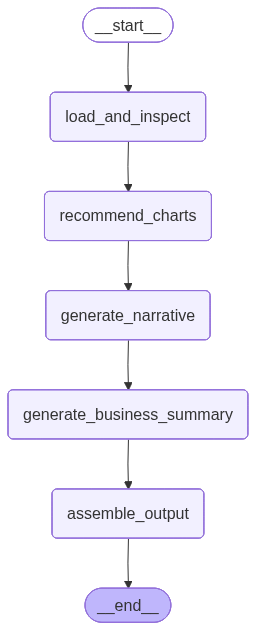

In [30]:
analysis_graph

In [29]:
result = analysis_graph.invoke(
    {
        "raw_input": {"csv_path": CSV_PATH},
        "analysis": {},
        "chart_plan": {},
        "narrative": {},
        "business_summary": {},
        "final_output": {},
        "report_markdown": ""
    }
)

print("File Name:", result["final_output"]["schema"]["file_name"])
print("Rows:", result["final_output"]["schema"]["row_count"])
print("Columns:", result["final_output"]["schema"]["column_count"])

/tmp/ipykernel_2578/3846755664.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_sample = pd.to_datetime(sample, errors="coerce")
/tmp/ipykernel_2578/3846755664.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_sample = pd.to_datetime(sample, errors="coerce")
/tmp/ipykernel_2578/3846755664.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_sample = pd.to_datetime(sample, errors="coerce")
/tmp/ipykernel_2578/3846755664.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pa

File Name: nyc_taxis.csv
Rows: 6433
Columns: 14


In [31]:
chart_recommendation_df = build_recommendation_df(result["chart_plan"])
chart_recommendation_df

,chart_type,title,columns,reason
0,missing_bar,Missing Values by Column,"dropoff_borough, dropoff_zone, payment, pickup_borough, pickup_zone",This quickly shows which columns need cleaning or imputation.
1,histogram,Distribution of total,total,"This helps inspect spread, skewness, and unusual value concentration."
2,bar,Top Categories in dropoff_borough,dropoff_borough,This shows category concentration and distribution clearly.
3,line,total Over Time by dropoff,"dropoff, total",This helps reveal time trends and directional movement.


In [ ]:
display(result["analysis"]["preview_df"])
display(result["analysis"]["schema_df"])

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


,column,dtype,role,non_null_count,missing_count,missing_pct,unique_count
0,color,object,categorical,6433,0,0.00,2
1,dropoff_borough,object,categorical,6388,45,0.70,5
2,dropoff_zone,object,categorical,6388,45,0.70,203
3,payment,object,categorical,6389,44,0.68,2
4,pickup_borough,object,categorical,6407,26,0.40,4
5,pickup_zone,object,categorical,6407,26,0.40,194
6,dropoff,datetime64[ns],datetime,6433,0,0.00,6425
7,pickup,datetime64[ns],datetime,6433,0,0.00,6414
8,distance,float64,numeric,6433,0,0.00,1079
9,fare,float64,numeric,6433,0,0.00,220


In [33]:
display(result["analysis"]["missing_df"])

if len(result["analysis"]["numeric_summary_df"]) > 0:
    display(result["analysis"]["numeric_summary_df"])

if len(result["analysis"]["categorical_summary_df"]) > 0:
    display(result["analysis"]["categorical_summary_df"])

if len(result["analysis"]["datetime_summary_df"]) > 0:
    display(result["analysis"]["datetime_summary_df"])

if len(result["analysis"]["correlations_df"]) > 0:
    display(result["analysis"]["correlations_df"].drop(columns=["abs_correlation"], errors="ignore"))

,column,missing_count,missing_pct
0,dropoff_borough,45,0.70
1,dropoff_zone,45,0.70
2,payment,44,0.68
3,pickup_borough,26,0.40
4,pickup_zone,26,0.40
5,color,0,0.00
6,distance,0,0.00
7,dropoff,0,0.00
8,fare,0,0.00
9,passengers,0,0.00


,column,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,nunique,skew
0,total,6433.0,18.517794,13.815570,1.3,10.80,14.16,20.30,174.82,0,0.0,898,3.093
1,fare,6433.0,13.091073,11.551804,1.0,6.50,9.50,15.00,150.00,0,0.0,220,3.217
2,distance,6433.0,3.024617,3.827867,0.0,0.98,1.64,3.21,36.70,0,0.0,1079,3.008
3,tip,6433.0,1.979220,2.448560,0.0,0.00,1.70,2.80,33.20,0,0.0,489,2.665
4,tolls,6433.0,0.325273,1.415267,0.0,0.00,0.00,0.00,24.02,0,0.0,16,5.075
5,passengers,6433.0,1.539251,1.203768,0.0,1.00,1.00,2.00,6.00,0,0.0,7,2.359


,column,unique_count,missing_count,missing_pct,top_value,top_frequency
0,dropoff_zone,203,45,0.70,Upper East Side North,245
1,pickup_zone,194,26,0.40,Midtown Center,230
2,dropoff_borough,5,45,0.70,Manhattan,5206
3,pickup_borough,4,26,0.40,Manhattan,5268
4,color,2,0,0.00,yellow,5451
5,payment,2,44,0.68,credit card,4577


,column,missing_count,missing_pct,min_date,max_date,unique_count
0,dropoff,0,0.0,2019-02-28 23:32:35,2019-04-01 00:13:58,6425
1,pickup,0,0.0,2019-02-28 23:29:03,2019-03-31 23:43:45,6414


,x,y,correlation
0,fare,total,0.974
1,distance,fare,0.920
2,distance,total,0.905
3,tolls,total,0.683
4,tip,total,0.646
5,distance,tolls,0.635
6,fare,tolls,0.609
7,fare,tip,0.489
8,distance,tip,0.453
9,tip,tolls,0.414


In [ ]:
chart_recommendation_df = build_recommendation_df(result["chart_plan"])
chart_recommendation_df

,chart_type,title,columns,reason
0,missing_bar,Missing Values by Column,"dropoff_borough, dropoff_zone, payment, pickup_borough, pickup_zone",This quickly shows which columns need cleaning or imputation.
1,histogram,Distribution of total,total,"This helps inspect spread, skewness, and unusual value concentration."
2,bar,Top Categories in dropoff_borough,dropoff_borough,This shows category concentration and distribution clearly.
3,line,total Over Time by dropoff,"dropoff, total",This helps reveal time trends and directional movement.


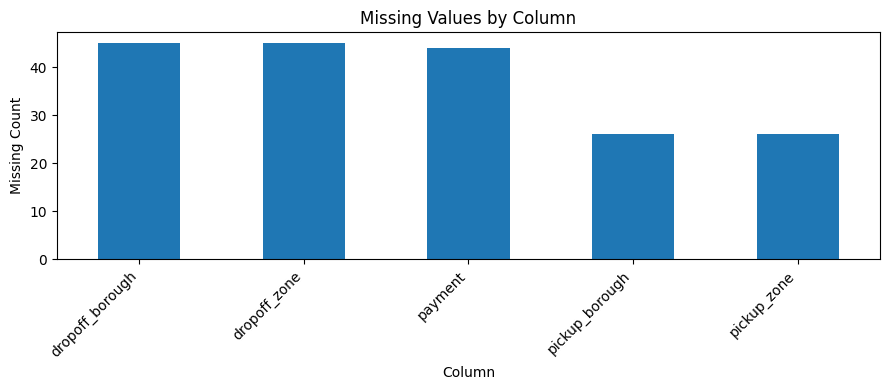

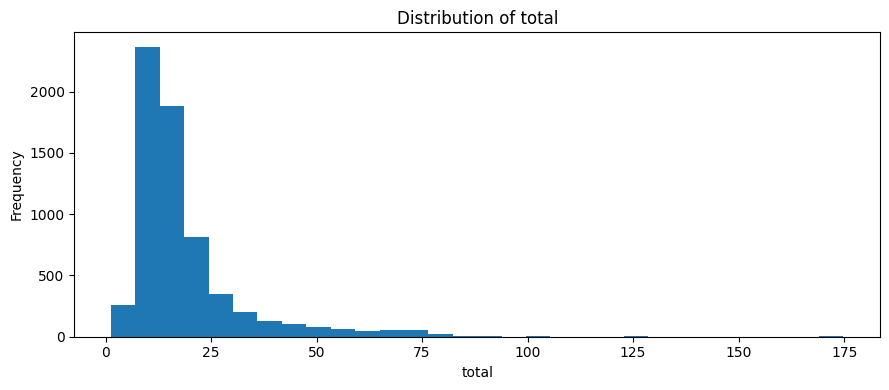

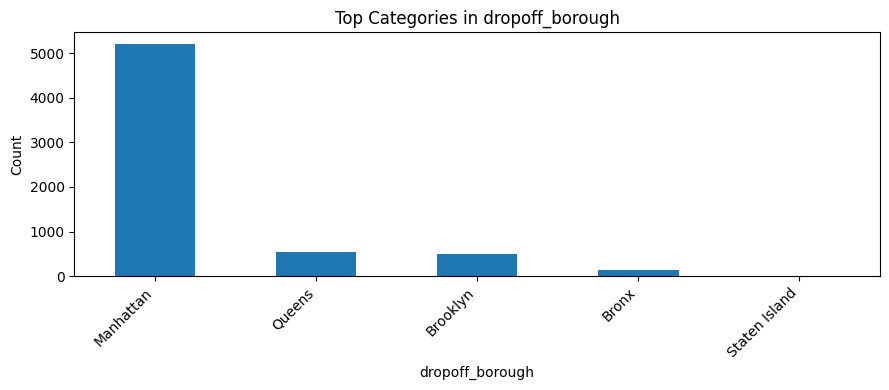

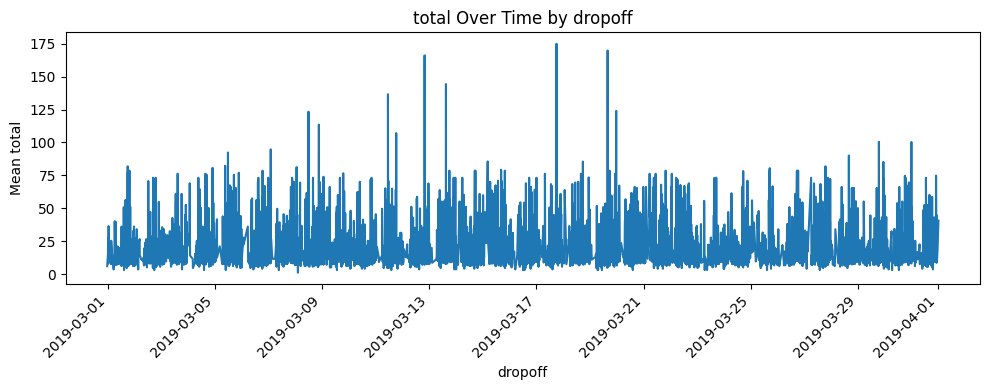

In [35]:
for chart in result["chart_plan"]["charts"]:
    plot_chart(result["analysis"]["df"], chart)

In [36]:
display(Markdown(result["report_markdown"]))

# Automatic Data Analysis Report

## Dataset Overview
This dataset, 'nyc_taxis.csv', contains 6433 records and 14 columns related to NYC taxi trips from late February to early April 2019. It includes details such as passenger count, trip distance, fare, tip, tolls, and total cost, along with pickup/dropoff locations (zone and borough), taxi color, and payment method. The dataset provides a snapshot of taxi activity over approximately one month.

## Top Insights
- Trip fare and distance are very strongly correlated with the total cost of a trip (0.974 and 0.905 respectively). Fare and distance themselves are also highly correlated (0.92).
- The average total cost for a taxi trip is approximately $18.52, with a median of $14.16, indicating a right-skewed distribution where many trips are less expensive, but some are significantly more.
- A significant majority of trips are served by 'yellow' taxis (5451 out of 6433 records) and 'credit card' is the most common payment method (4577 records).
- Manhattan is the primary borough for both pickups (5268 records) and dropoffs (5206 records), suggesting it's the central hub for taxi activity.
- Most taxi trips involve 1 or 2 passengers, with a median of 1 passenger and 75% of trips having 2 or fewer passengers. However, some trips accommodate up to 6 passengers.
- Several numerical columns, including 'total', 'fare', 'distance', 'tip', 'tolls', and 'passengers', exhibit right-skewed distributions, suggesting the presence of higher-value outliers or a concentration of data towards lower values.

## Data Quality Notes
- There are 186 missing values across 5 columns. 'dropoff_borough' and 'dropoff_zone' have the highest percentage of missing values at 0.7% (45 records each), followed closely by 'payment' at 0.68% (44 records). 'pickup_borough' and 'pickup_zone' each have 0.4% missing values (26 records each).
- No duplicate rows were found in the dataset.
- The 'distance' column contains trips with a value of 0.0, which might indicate canceled trips, very short non-moving trips, or data errors. Similarly, the 'passengers' column includes trips with 0 passengers, which warrants investigation for validity.
- The dataset covers a relatively short period (approximately one month in early 2019), which might limit the generalizability of time-based insights to broader periods or current trends.

## Recommended Focus Areas
- Address the missing values in location-related columns ('dropoff_borough', 'dropoff_zone', 'pickup_borough', 'pickup_zone') and 'payment' to ensure complete contextual information for analysis.
- Investigate trips with 0.0 distance or 0 passengers to determine if they represent valid scenarios (e.g., vehicle relocation, cancellations) or data anomalies that need cleaning.
- Further analyze the highly correlated variables like 'fare', 'distance', and 'total' to understand their interplay and contribution to trip costs, potentially through regression analysis or scatter plots.
- Explore the reasons behind the strong right-skewness in cost-related numerical columns ('total', 'fare', 'distance', 'tip', 'tolls') to identify potential outliers or specific categories of trips that drive these distributions.
- Conduct a more in-depth geographical analysis, focusing on Manhattan and other boroughs, to understand popular routes, peak pickup/dropoff zones, and potential discrepancies in service coverage.

## Executive Summary
This analysis of NYC taxi trip data from late February to early April 2019, comprising 6433 records, reveals key operational insights. We observe a strong correlation between trip distance, fare, and total cost. The average total trip cost is around $18.52, with a notable right-skewness indicating a spectrum of trip prices. 'Yellow' taxis and 'credit card' payments dominate the market, and Manhattan consistently serves as the primary borough for both pickups and dropoffs. Data quality concerns include missing values in location and payment columns, and anomalous records with zero distance or passengers warrant further investigation.

## Key Trends
- Trip total cost is highly correlated with both fare (0.974) and distance (0.905), with fare and distance also showing a strong correlation (0.92).
- The average taxi trip costs approximately $18.52, though the median of $14.16 suggests that many trips are less expensive, with some outliers driving up the average.
- The vast majority of taxi services are provided by 'yellow' cabs and paid for via 'credit card'.
- Manhattan is the predominant borough for both taxi pickups and dropoffs, indicating its central role in taxi operations.
- Most taxi trips involve one or two passengers, with 75% of trips having two or fewer passengers.
- Numerical metrics like total cost, fare, distance, tip, tolls, and passengers exhibit right-skewed distributions, pointing to a concentration of lower values and occasional higher values.

## Risks
- Approximately 0.7% of dropoff location data (borough and zone) and 0.68% of payment information are missing, which could impact analyses requiring complete trip context.
- Records with zero distance or zero passengers are present, potentially indicating invalid or anomalous data entries that could distort performance metrics if not properly handled.
- The dataset covers a limited period of just over one month in early 2019, which may restrict the generalizability of trends to longer periods or current conditions.
- Missing pickup location data (borough and zone) for 0.4% of records also presents a data quality issue.

## Next Steps
- Prioritize addressing missing values in 'dropoff_borough', 'dropoff_zone', 'pickup_borough', 'pickup_zone', and 'payment' columns to enhance data completeness for analysis.
- Investigate trips recorded with 0.0 distance or 0 passengers to determine their validity and implement appropriate data handling strategies.
- Conduct in-depth analysis on the highly correlated variables (fare, distance, total) to understand their combined impact on trip costs and identify potential pricing strategies or factors.
- Perform further geographical analysis focusing on Manhattan's central role and other boroughs to identify popular routes, peak times, and service demand patterns.
- Explore the reasons behind the right-skewed distributions in cost-related numerical columns to identify specific trip characteristics or outliers contributing to these patterns.

## Recommended Charts
- **Missing Values by Column** (missing_bar) — This quickly shows which columns need cleaning or imputation.
- **Distribution of total** (histogram) — This helps inspect spread, skewness, and unusual value concentration.
- **Top Categories in dropoff_borough** (bar) — This shows category concentration and distribution clearly.
- **total Over Time by dropoff** (line) — This helps reveal time trends and directional movement.

In [37]:
print(json.dumps(result["final_output"], indent=2, ensure_ascii=False, default=str))

{
  "schema": {
    "file_name": "nyc_taxis.csv",
    "row_count": 6433,
    "column_count": 14,
    "numeric_columns": [
      "passengers",
      "distance",
      "fare",
      "tip",
      "tolls",
      "total"
    ],
    "categorical_columns": [
      "color",
      "payment",
      "pickup_zone",
      "dropoff_zone",
      "pickup_borough",
      "dropoff_borough"
    ],
    "datetime_columns": [
      "pickup",
      "dropoff"
    ],
    "text_like_columns": [],
    "parsed_datetime_columns": [
      "pickup",
      "dropoff"
    ],
    "duplicate_rows": 0,
    "missing_cells": 186
  },
  "recommended_charts": [
    {
      "chart_type": "missing_bar",
      "title": "Missing Values by Column",
      "columns": [
        "dropoff_borough",
        "dropoff_zone",
        "payment",
        "pickup_borough",
        "pickup_zone"
      ],
      "reason": "This quickly shows which columns need cleaning or imputation."
    },
    {
      "chart_type": "histogram",
      "title": 